In [111]:
import pandas as pd
#import pyarrow as pa
#import pyarrow.parquet as pq
from fuzzywuzzy import fuzz
import re
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# EJERCICIO CLASE PRACTICA

In [112]:
# Importamos los datos, salteando todo lo que figura en las primeras 4 filas (completar ruta)
data_internet = pd.read_csv('datasets//data_internet.csv', skiprows = 4)

# Filtramos sólo algunos países
lista_paises = ['Iceland', 'Norway', 'United Kingdom', 'Japan', 'Canada', 'Germany', 'New Zealand',
                  'France', 'Israel', 'Argentina', 'United States', 'Chile', 'Italy', 'Brazil', 'Mexico',
                  'South Africa', 'China', 'Algeria', 'India', 'Kenia']

data_internet_filtrado = data_internet[(data_internet['Country Name'].isin(lista_paises))]

# Eliminamos columnas innecesarias
data_internet_filtrado = data_internet_filtrado.drop(['Country Code', 'Indicator Name', 'Indicator Code', 'Unnamed: 68'], axis = 1)

# Nos quedamos únicamente con las columnas que tienen datos para todos los países que seleccionamos
data_internet_filtrado = data_internet_filtrado.dropna(axis = 1)

# Seteamos Country Name como index
data_internet_filtrado.set_index('Country Name', inplace = True)

In [113]:
df = data_internet_filtrado.loc[['Argentina', 'India', 'United States']]
df.head()

,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
Country Name,,,,,,,,,,,,,,,,,,,,,
Argentina,0.000000,0.000000,0.002993,0.029527,0.043706,0.086277,0.141955,0.280340,0.830767,3.284482,...,55.8,59.9,64.7,68.043064,70.968981,74.294907,77.700000,79.946952,85.514386,87.150707
India,0.000000,0.000000,0.000111,0.000218,0.001070,0.026229,0.046334,0.070768,0.139027,0.273224,...,11.1,12.3,13.5,14.900000,16.500000,18.200000,20.081300,29.523511,43.405443,46.310000
United States,0.784729,1.163194,1.724203,2.271673,4.862781,9.237088,16.419353,21.616401,30.093197,35.848724,...,74.7,71.4,73.0,74.554202,85.544421,87.274889,88.498903,89.430285,90.620470,91.753208


In [114]:
df = df.reset_index()
df.head()

,Country Name,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Argentina,0.000000,0.000000,0.002993,0.029527,0.043706,0.086277,0.141955,0.280340,0.830767,...,55.8,59.9,64.7,68.043064,70.968981,74.294907,77.700000,79.946952,85.514386,87.150707
1,India,0.000000,0.000000,0.000111,0.000218,0.001070,0.026229,0.046334,0.070768,0.139027,...,11.1,12.3,13.5,14.900000,16.500000,18.200000,20.081300,29.523511,43.405443,46.310000
2,United States,0.784729,1.163194,1.724203,2.271673,4.862781,9.237088,16.419353,21.616401,30.093197,...,74.7,71.4,73.0,74.554202,85.544421,87.274889,88.498903,89.430285,90.620470,91.753208


In [115]:
# Convertimos a formato largo
df_largo = pd.melt(df, id_vars= "Country Name", var_name= 'Anio', value_name = 'Porcentaje')
df_largo

,Country Name,Anio,Porcentaje
0,Argentina,1990,0.000000
1,India,1990,0.000000
2,United States,1990,0.784729
3,Argentina,1991,0.000000
4,India,1991,0.000000
...,...,...,...
91,India,2020,43.405443
92,United States,2020,90.620470
93,Argentina,2021,87.150707
94,India,2021,46.310000


In [116]:
# Convertimos los años a tipo int
df_largo['Anio'] = df_largo['Anio'].astype(int)
df_largo.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Country Name  96 non-null     str    
 1   Anio          96 non-null     int64  
 2   Porcentaje    96 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 3.3 KB


<Axes: xlabel='Anio', ylabel='Porcentaje'>

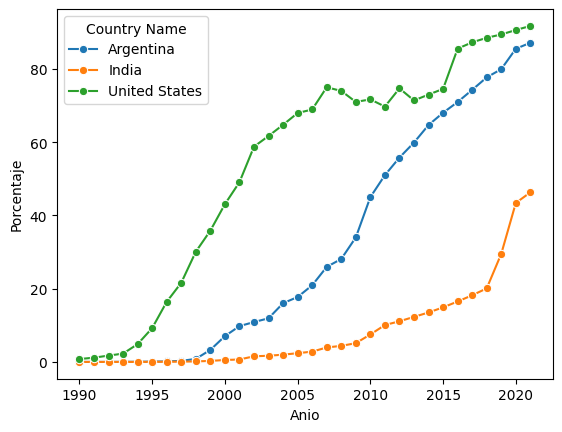

In [117]:
sns.lineplot(x= 'Anio', y= 'Porcentaje', hue='Country Name', marker= 'o', data=df_largo)

# EJERCICIO 1

In [118]:
iris = pd.read_csv("datasets/iris.csv")
iris.head(15)

,id,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [119]:
iris.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               150 non-null    int64  
 1   sepal_length_cm  150 non-null    float64
 2   sepal_width_cm   150 non-null    float64
 3   petal_length_cm  150 non-null    float64
 4   petal_width_cm   150 non-null    float64
 5   species          150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB


PUNTO 1

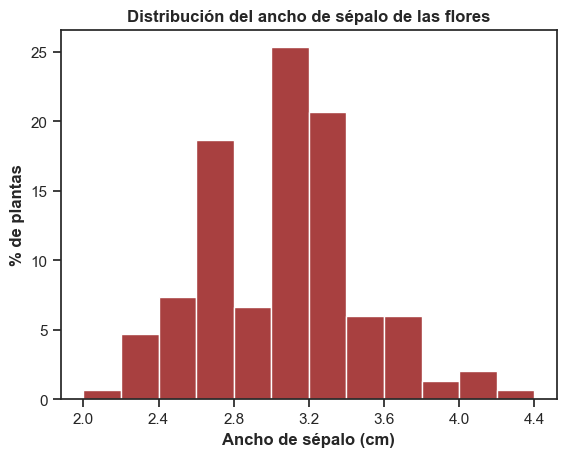

In [ ]:
# Configuramos el estilo visual con marcas en los ejes
sns.set_theme(style='ticks')

# Dibujamos el histograma. El parametro stat=percent transforma el eje vertical para que muestre 
# porcentajes en lugar de frecuencias
# Ademas seteamos el ancho de los intervalos (binwidth) y el rango del grafico (binrange)
sns.histplot(data=iris, x='sepal_width_cm', color='darkred', stat='percent', binwidth=0.2, binrange=(2.0, 4.4))

# Definimos que las marcas del eje X vayan de 2.0 a 4.4, saltando de 0.4
plt.xticks(np.arange(2.0, 4.5, 0.4))

# Personalizamos los títulos según la consigna
plt.title('Distribución del ancho de sépalo de las flores', fontweight='bold')
plt.xlabel('Ancho de sépalo (cm)', fontweight='bold')
plt.ylabel('% de plantas', fontweight='bold')
plt.show()

# EJERCICIO 2

PUNTO 1

In [120]:
temperaturas = pd.read_fwf("datasets/registro_temperatura365d_smn.txt", encoding='latin1')
temperaturas.head(15)

,FECHA,TMAX,TMIN,NOMBRE
0,--------,-----,-----,----------------------------------------
1,10042026,21.1,13.8,AEROPARQUE AERO
2,10042026,22.6,7.2,AZUL AERO
3,10042026,24.8,11.4,BAHIA BLANCA AERO
4,10042026,24.6,1.2,BARILOCHE AERO
5,10042026,-11.4,-18.6,BASE BELGRANO II
6,10042026,1.1,-4.1,BASE CARLINI (EX JUBANY)
7,10042026,-3.4,-8.8,BASE ESPERANZA
8,10042026,-3.9,-14.4,BASE MARAMBIO
9,10042026,1.0,-4.0,BASE ORCADAS


In [121]:
temperaturas.info()

<class 'pandas.DataFrame'>
RangeIndex: 42980 entries, 0 to 42979
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   FECHA   42980 non-null  str  
 1   TMAX    41004 non-null  str  
 2   TMIN    42278 non-null  str  
 3   NOMBRE  42980 non-null  str  
dtypes: str(4)
memory usage: 2.6 MB


In [122]:
# vemos que tenemos una fila completa de guiones (fila 0), la eliminamos
temperaturas.drop(index=0, inplace=True)
temperaturas.head(15)

,FECHA,TMAX,TMIN,NOMBRE
1,10042026,21.1,13.8,AEROPARQUE AERO
2,10042026,22.6,7.2,AZUL AERO
3,10042026,24.8,11.4,BAHIA BLANCA AERO
4,10042026,24.6,1.2,BARILOCHE AERO
5,10042026,-11.4,-18.6,BASE BELGRANO II
6,10042026,1.1,-4.1,BASE CARLINI (EX JUBANY)
7,10042026,-3.4,-8.8,BASE ESPERANZA
8,10042026,-3.9,-14.4,BASE MARAMBIO
9,10042026,1.0,-4.0,BASE ORCADAS
10,10042026,3.1,-7.3,BASE SAN MARTIN


In [123]:
# Como vemos que hay valores faltantes en TMAX y en TMIN, borramos esas filas ya que no tiene sentido dejarlas.
# Con el parametro how=all le indicamos a pandas que elimine las filas donde todos son NA
temperaturas.dropna(subset=['TMAX', 'TMIN'], inplace=True, how='all')
temperaturas.info()

<class 'pandas.DataFrame'>
Index: 42739 entries, 1 to 42979
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   FECHA   42739 non-null  str  
 1   TMAX    41003 non-null  str  
 2   TMIN    42277 non-null  str  
 3   NOMBRE  42739 non-null  str  
dtypes: str(4)
memory usage: 2.9 MB


In [124]:
# Tambien notamos que la fecha se encuentra en formato str, lo pasamos a formato adecuado. El parametro format sirve para aclararle 
# a pandas como se encuentra la columna fecha antes de la correcion
temperaturas['FECHA'] = pd.to_datetime(temperaturas['FECHA'], format='%d%m%Y')
temperaturas.info()

<class 'pandas.DataFrame'>
Index: 42739 entries, 1 to 42979
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   FECHA   42739 non-null  datetime64[us]
 1   TMAX    41003 non-null  str           
 2   TMIN    42277 non-null  str           
 3   NOMBRE  42739 non-null  str           
dtypes: datetime64[us](1), str(3)
memory usage: 2.6 MB


In [125]:
# Corrijo formatos de minimos y maximos (str a float)
temperaturas['TMAX'] = pd.to_numeric(temperaturas['TMAX'])
temperaturas['TMIN'] = pd.to_numeric(temperaturas['TMIN'])


PUNTO 2

In [128]:
# Ahora creamos una columna mes para poder hacer los analisis correspondientes.
# Utilizamos la herramienta .dt para manejar fechas
temperaturas['AÑO_MES'] = temperaturas['FECHA'].dt.to_period('M')

# Tengo que crear funcion iqr
def iqr(x):
    return x.quantile(0.75)-x.quantile(0.25)

# Ahora creamos la tabla de resumen para los minimos y maximos por mes
minimas = temperaturas.groupby('AÑO_MES')[['TMIN','TMAX']].agg(['mean','median','std', iqr]).round(2)
minimas

TMIN                       TMAX                  
          mean median   std    iqr   mean median   std  iqr
AÑO_MES                                                    
2025-04   9.66  10.30  6.27   8.00  20.72  22.00  7.02  7.9
2025-05   7.99   8.70  7.78  10.82  18.44  19.80  8.11  9.2
2025-06   2.46   2.60  6.13   6.60  14.06  15.50  6.87  7.5
2025-07   3.72   4.50  6.60   8.40  15.07  15.50  7.61  9.1
2025-08   4.86   5.20  6.78   7.60  17.03  18.00  7.95  8.9
2025-09   7.42   7.80  7.31   8.40  20.14  21.05  8.47  9.5
2025-10   9.76  10.50  7.06   8.30  23.04  24.50  8.80  9.1
2025-11  12.22  13.20  6.66   7.40  25.28  26.50  8.68  9.3
2025-12  15.24  16.60  6.34   7.30  28.22  30.30  8.17  7.4
2026-01  15.69  17.20  6.26   7.50  28.81  30.60  7.68  7.2
2026-02  15.28  17.00  6.75   8.00  27.91  29.60  8.01  6.5
2026-03  14.03  15.80  7.09   9.10  25.52  26.80  7.87  6.9
2026-04  11.69  12.15  7.54  10.30  22.20  22.55  8.09  8.3

PUNTO 3

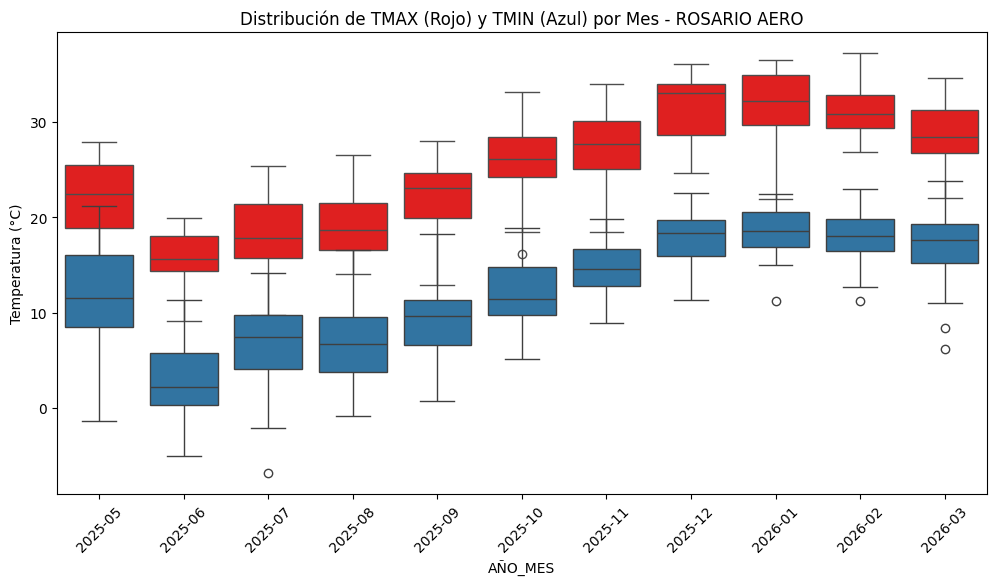

In [151]:
# Primero filtramos por fechas y lugar
fecha_inicio = '2025-05-01'
fecha_fin = '2026-04-01'
filtro_temp = temperaturas[((temperaturas['FECHA'] >= fecha_inicio) & (temperaturas['FECHA'] < fecha_fin)) & (temperaturas['NOMBRE'] == 'ROSARIO AERO')]

# Corregimos el orden de los valores, lo ponemos en ascendente
filtro_temp = filtro_temp.sort_values('FECHA', ascending=True)

# Ahora graficamos
plt.figure(figsize=(12, 6))
sns.boxplot(x='AÑO_MES', y='TMAX', data=filtro_temp, color='red')
sns.boxplot(x='AÑO_MES', y='TMIN', data=filtro_temp)
plt.title('Distribución de TMAX (Rojo) y TMIN (Azul) por Mes - ROSARIO AERO')
plt.xticks(rotation=45)
plt.ylabel('Temperatura (°C)')
plt.show()

PUNTO 4

### a. ¿Cuál fue el mes del último año con la mayor temperatura máxima mediana?
    Notamos en el gradifico que se trata del 12/2025

### b. ¿Cuál fue el mes del último año con la menor temperatura mínima mediana?
    Se nota a 06/2025 como el mes con la menor temp mediana

### c. Considerando la variabilidad del 50 % central de las temperaturas registradas en el mes, ¿cuál fue el mes del último año con una menor dispersión tanto en sus temperaturas mínimas como en sus temperaturas máximas?
    El mes con menos variabilidad en ambas temperaturas es 02/2026

### d. ¿Cuál fue el mes del último año que presentó una mayor amplitud en sus temperaturas mínimas registradas?
    El mes con mayor variabilidad en sus temperaturas minimas es 05/2025

### e. Considerando los meses del invierno 2025, ¿existió algún mes en el cual se haya registrado una temperatura máxima atípica en relación al resto de los registros de ese mes?
    De los graficos no se notan temperaturas maximas atipicas en el invierno del 2025



# EJERCICIO 3

In [154]:
penguins = sns.load_dataset('penguins')
penguins.head(15)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
